In [3]:
# IMPORTAÇÃO, PREPARAÇÃO E AMOSTRAGEM 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
import itertools

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

print("A carregar os dados a partir da pasta data/raw/ ...")

# Caminhos
path_customers = '../data/raw/olist_customers_dataset.csv'
path_orders = '../data/raw/olist_orders_dataset.csv'
path_items = '../data/raw/olist_order_items_dataset.csv'
path_payments = '../data/raw/olist_order_payments_dataset.csv'

df_customers = pd.read_csv(path_customers)
df_orders = pd.read_csv(path_orders)
df_items = pd.read_csv(path_items)
df_payments = pd.read_csv(path_payments)

# Merge e limpeza
df_merged = pd.merge(df_orders, df_customers, on='customer_id', how='inner')
df_merged = pd.merge(df_merged, df_items, on='order_id', how='inner')
df_master = pd.merge(df_merged, df_payments, on='order_id', how='inner')
df_clean = df_master.dropna(subset=['order_delivered_customer_date', 'order_approved_at'])

# AMOSTRAGEM CRÍTICA: 15.000 linhas para não esgotar a RAM do computador local
df_sample = df_clean.sample(n=15000, random_state=42).copy()

features = ['price', 'freight_value', 'payment_installments', 'payment_value']
X = df_sample[features]

# Padronização (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA para futura visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"✅ Base pronta com amostra de {X_scaled.shape[0]} registos para processamento seguro.")


A carregar os dados a partir da pasta data/raw/ ...
✅ Base pronta com amostra de 15000 registos para processamento seguro.


A calcular o K ideal (pode demorar cerca de 1 minuto)...


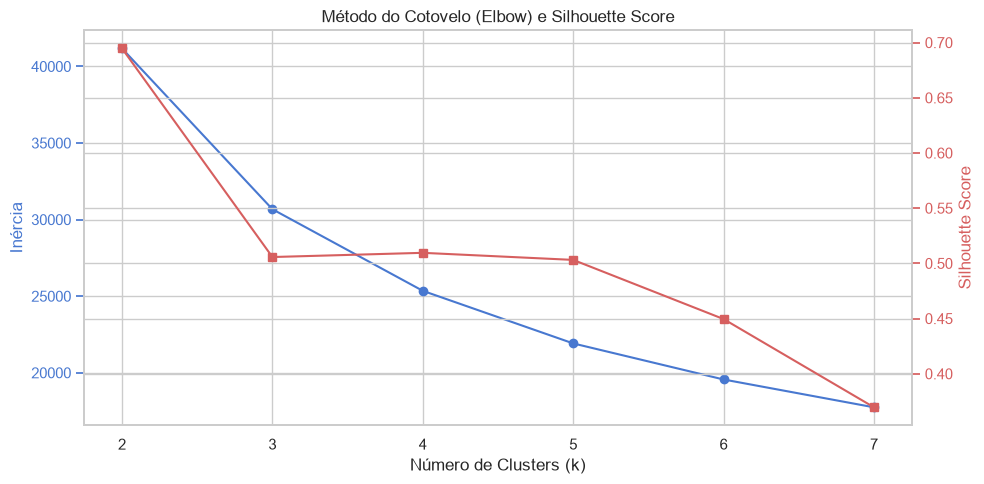

🎯 O número ideal de clusters (K) sugerido pelo Silhouette é: 2

--- Teste de Estabilidade do K-Means (Seeds variadas) ---
Estabilidade Média (Adjusted Rand Index - ARI): 1.0000
✅ Resultado: Excelente estabilidade! Os clusters formam-se de forma consistente independentemente da semente.


In [4]:
# 1. DESCOBRIR O 'K' IDEAL (ELBOW METHOD E SILHOUETTE)
print("A calcular o K ideal (pode demorar cerca de 1 minuto)...")
inercia = []
silhuetas = []
K_range = range(2, 8)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    inercia.append(kmeans_temp.inertia_)
    silhuetas.append(silhouette_score(X_scaled, labels_temp))

# Gráficos de Avaliação do K
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(K_range, inercia, 'bo-', label='Inércia (Elbow)')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhuetas, 'rs-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params('y', colors='r')

plt.title('Método do Cotovelo (Elbow) e Silhouette Score')
fig.tight_layout()
plt.show()

melhor_k = K_range[np.argmax(silhuetas)]
print(f"🎯 O número ideal de clusters (K) sugerido pelo Silhouette é: {melhor_k}")
k_final = melhor_k 

# %% [Célula 3] 2. TESTE DE ESTABILIDADE (ARI)
print("\n--- Teste de Estabilidade do K-Means (Seeds variadas) ---")
seeds = [0, 1, 2, 42, 100]
labels_por_seed = []

for seed in seeds:
    km = KMeans(n_clusters=k_final, random_state=seed, n_init=10)
    labels_por_seed.append(km.fit_predict(X_scaled))

# Comparar as execuções aos pares
ari_scores = []
pares = list(itertools.combinations(range(len(seeds)), 2))
for i, j in pares:
    ari = adjusted_rand_score(labels_por_seed[i], labels_por_seed[j])
    ari_scores.append(ari)

media_ari = np.mean(ari_scores)
print(f"Estabilidade Média (Adjusted Rand Index - ARI): {media_ari:.4f}")
if media_ari > 0.8:
    print("✅ Resultado: Excelente estabilidade! Os clusters formam-se de forma consistente independentemente da semente.")
else:
    print("⚠️ Resultado: Estabilidade baixa. Os agrupamentos variam muito.")


In [5]:
# 3. TESTAR DIFERENTES MÉTRICAS DE DISTÂNCIA
print(f"\n--- Teste de Distâncias (Euclidiana, Manhattan, Cosine) com K={k_final} ---")
metricas_dist = ['euclidean', 'manhattan', 'cosine']
resultados_dist = []

for metrica in metricas_dist:
    hc = AgglomerativeClustering(n_clusters=k_final, metric=metrica, linkage='average')
    labels_hc = hc.fit_predict(X_scaled)
    if len(np.unique(labels_hc)) > 1:
        sil = silhouette_score(X_scaled, labels_hc, metric=metrica)
        resultados_dist.append({'Métrica': metrica.capitalize(), 'Silhouette': sil})

df_dist = pd.DataFrame(resultados_dist)
display(df_dist)



--- Teste de Distâncias (Euclidiana, Manhattan, Cosine) com K=2 ---


,Métrica,Silhouette
0,Euclidean,0.923033
1,Manhattan,0.918576
2,Cosine,0.591040


In [6]:
#  4. COMPARAÇÃO DOS ALGORITMOS FINAIS (Métricas Coesão/Separação)
print("\n--- A avaliar Algoritmos: K-Means vs Hierárquico vs DBSCAN ---")

# 1. K-Means
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels_km = kmeans_final.fit_predict(X_scaled)

# 2. Hierárquico (Euclidiano, Ward)
hc_final = AgglomerativeClustering(n_clusters=k_final, metric='euclidean', linkage='ward')
labels_hc = hc_final.fit_predict(X_scaled)

# 3. DBSCAN (Densidade) - eps estimado com base na normalização
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_db = dbscan.fit_predict(X_scaled)

algoritmos = [('K-Means', labels_km), ('Hierárquico', labels_hc), ('DBSCAN', labels_db)]
resultados_alg = []

for nome, labels in algoritmos:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
    else:
        sil, db, ch = 0, 0, 0
        
    resultados_alg.append({
        'Algoritmo': nome,
        'Clusters Encontrados': n_clusters,
        'Silhouette (↑ melhor)': round(sil, 4),
        'Davies-Bouldin (↓ melhor)': round(db, 4),
        'Calinski-Harabasz (↑ melhor)': round(ch, 2)
    })

df_res = pd.DataFrame(resultados_alg)
display(df_res)



--- A avaliar Algoritmos: K-Means vs Hierárquico vs DBSCAN ---


,Algoritmo,Clusters Encontrados,Silhouette (↑ melhor),Davies-Bouldin (↓ melhor),Calinski-Harabasz (↑ melhor)
0,K-Means,2,0.6947,1.0271,6857.29
1,Hierárquico,2,0.5804,1.2167,5729.24
2,DBSCAN,2,0.4393,1.2984,2879.84


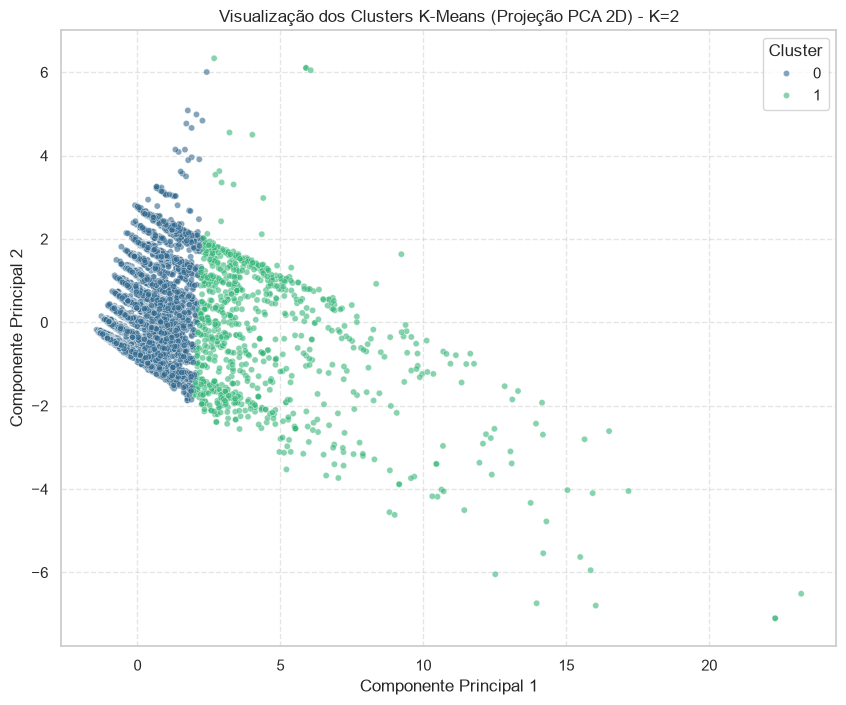


--- Perfil Médio de Cada Cluster (K-Means) ---


,price,freight_value,payment_installments,payment_value
Cluster,,,,
0,91.29,18.18,2.75,132.88
1,603.81,53.93,6.19,829.75


In [7]:
# 5. VISUALIZAÇÃO DOS CLUSTERS (Usando o K-Means e PCA)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_km, palette='viridis', alpha=0.6, s=20)
plt.title(f'Visualização dos Clusters K-Means (Projeção PCA 2D) - K={k_final}')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Interpretação rápida do que cada cluster representa
df_sample['Cluster'] = labels_km
print("\n--- Perfil Médio de Cada Cluster (K-Means) ---")
display(df_sample.groupby('Cluster')[features].mean().round(2))